In [41]:
!pip install -q imbalanced-learn

                REAL-WORLD PROBLEM
                       ↓
             Business Understanding
                       ↓
                Data Collection
                       ↓
                Data Understanding
                       ↓
                     EDA
                       ↓
             Data Cleaning/Wrangling
                       ↓
              Feature Engineering
                       ↓
              Feature Selection
                       ↓
                Train/Test Split
                       ↓
                Preprocessing
              ┌────────┴────────┐
              ↓                 ↓
        Numerical            Categorical
        Imputation            Imputation
              ↓                 ↓
           Scaling          One-Hot Encoding
              └────────┬────────┘
                       ↓
                  ML Modeling
                       ↓
             ┌─────────┴─────────┐
             ↓                   ↓
      Logistic Regression   Random Forest
             ↓                   ↓
             └─────────┬─────────┘
                       ↓
              Cross Validation
                       ↓
             Hyperparameter Tuning
                       ↓
                 Evaluation
                       ↓
      ┌────────────────┼────────────────┐
      ↓                ↓                ↓
 Accuracy          F1/Recall        ROC-AUC/PR-AUC
                       ↓
              Feature Importance
                       ↓
              Business Interpretation
                       ↓
                New Prediction
                       ↓
                Save/Deploy Model

In [42]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.feature_selection import SelectKBest, f_classif

import joblib

from imblearn.over_sampling import SMOTE

In [43]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [44]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Rows: 7043
Columns: 21

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [45]:
print(df["Churn"].value_counts())

print("\nPercentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [46]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

Series([], dtype: int64)


What does errors="coerce" do?
Invalid values become NaN

In [47]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print(df["TotalCharges"].dtype)

float64


In [48]:
missing = df.isnull().sum()

missing_percentage = (
    missing / len(df) * 100
).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percentage
})

display(
    missing_table[
        missing_table["Missing Count"] > 0
    ]
)

,Missing Count,Missing %
TotalCharges,11,0.156183


In [49]:
display(df.describe())
display(df.describe(include="object"))

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


Exploratory Data Analysis

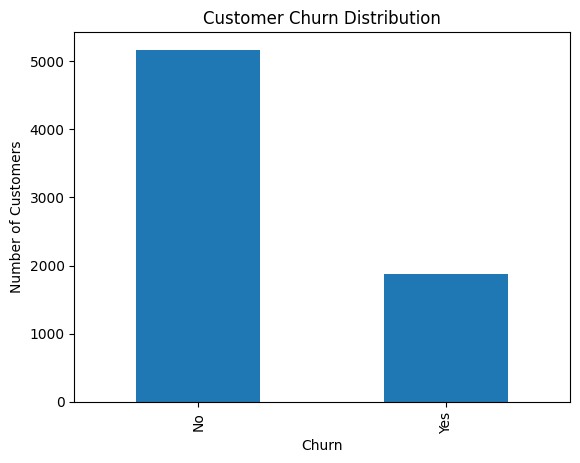

In [50]:
df["Churn"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

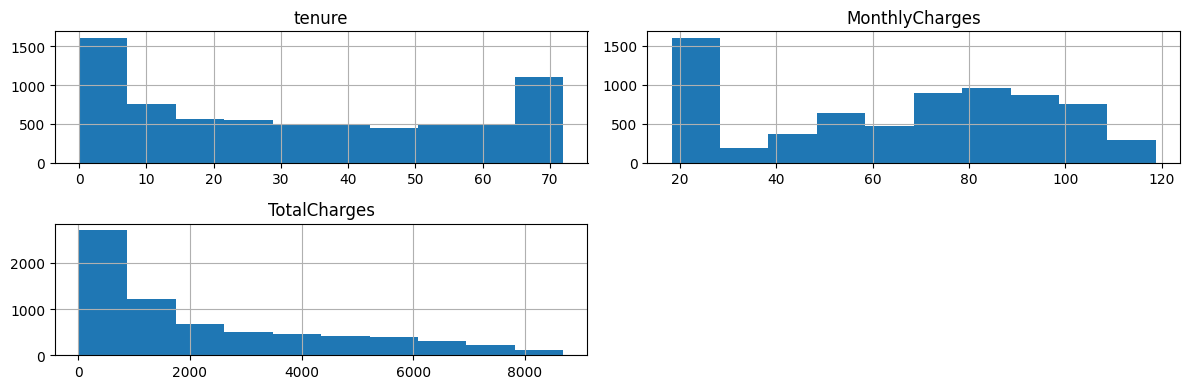

In [51]:
numeric_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

df[numeric_columns].hist(
    figsize=(12, 4)
)

plt.tight_layout()
plt.show()

Outlier detection

IQR = Q3 - Q1

Lower bound = Q1 - 1.5 × IQR

Upper bound = Q3 + 1.5 × IQR

In [52]:
for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(
        col,
        "→",
        len(outliers),
        "outliers"
    )

tenure → 0 outliers
MonthlyCharges → 0 outliers
TotalCharges → 0 outliers


Feature engineering

Tenure groups

0–12 months     → New

13–36 months    → Medium

37+ months      → Loyal

In [53]:
def tenure_group(tenure):

    if tenure <= 12:
        return "New"

    elif tenure <= 36:
        return "Medium"

    else:
        return "Loyal"


df["TenureGroup"] = df["tenure"].apply(
    tenure_group
)

df[["tenure", "TenureGroup"]].head(10)

,tenure,TenureGroup
0,1,New
1,34,Medium
2,2,New
3,45,Loyal
4,2,New
5,8,New
6,22,Medium
7,10,New
8,28,Medium
9,62,Loyal


In [54]:
df["AverageMonthlySpend"] = (
    df["TotalCharges"] /
    df["tenure"].replace(0, np.nan)
)

df["AverageMonthlySpend"] = (
    df["AverageMonthlySpend"]
    .fillna(df["MonthlyCharges"])
)

df[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "AverageMonthlySpend"
    ]
].head()

,tenure,MonthlyCharges,TotalCharges,AverageMonthlySpend
0,1,29.85,29.85,29.850000
1,34,56.95,1889.50,55.573529
2,2,53.85,108.15,54.075000
3,45,42.30,1840.75,40.905556
4,2,70.70,151.65,75.825000


In [55]:
corr = df[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "AverageMonthlySpend"
    ]
].corr()

display(corr)

,tenure,MonthlyCharges,TotalCharges,AverageMonthlySpend
tenure,1.000000,0.247900,0.825880,0.247234
MonthlyCharges,0.247900,1.000000,0.651065,0.996244
TotalCharges,0.825880,0.651065,1.000000,0.650915
AverageMonthlySpend,0.247234,0.996244,0.650915,1.000000


In [56]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [57]:
X = df.drop(columns=["Churn"])

y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 22)
y shape: (7043,)


In [58]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AverageMonthlySpend']

Categorical features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']


In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (5634, 22)
Testing : (1409, 22)


Data preprocessing pipeline



For numerical features:

Missing values -> Median ->
StandardScaler


For categorical features:

Missing values ->
Most frequent -> OneHotEncoder




In [60]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [61]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [62]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [63]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'AverageMonthlySpend']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['customerID', 'gender',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'TenureGroup'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [64]:
y_pred = logistic_model.predict(X_test)

y_prob = logistic_model.predict_proba(
    X_test
)[:, 1]

In [65]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

pr_auc = average_precision_score(
    y_test,
    y_prob
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)
print("PR-AUC   :", pr_auc)

Accuracy : 0.7508871540099361
Precision: 0.5217391304347826
Recall   : 0.7379679144385026
F1 Score : 0.6112956810631229
ROC-AUC  : 0.8415045596631273
PR-AUC   : 0.6323272078157033


In [66]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.52      0.74      0.61       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409



In [67]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[782 253]
 [ 98 276]]


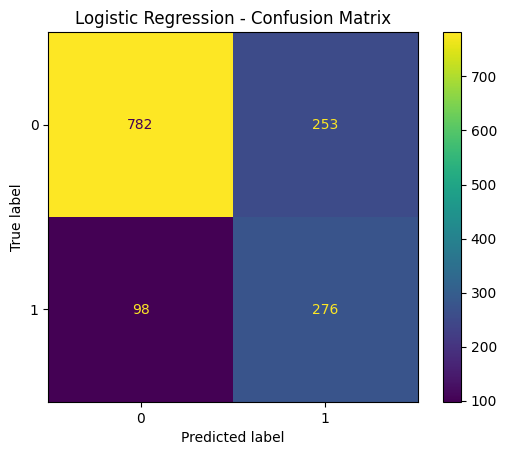

In [68]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Logistic Regression - Confusion Matrix")

plt.show()

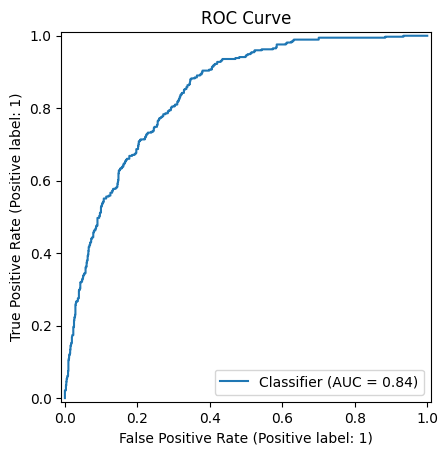

In [69]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve")

plt.show()

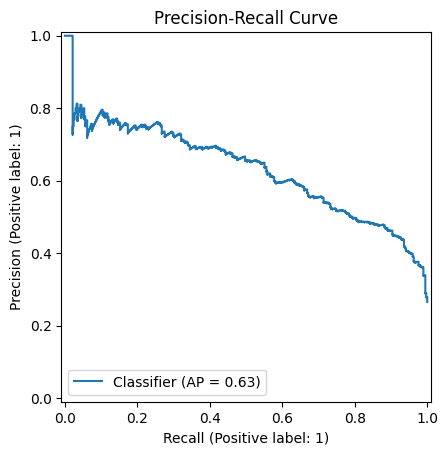

In [70]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title(
    "Precision-Recall Curve"
)

plt.show()

In [71]:
rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'AverageMonthlySpend']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle...
                                                  ['customerID', 'gender',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'TenureGroup'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [72]:
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(
    X_test
)[:, 1]

print(
    "Accuracy:",
    accuracy_score(y_test, rf_pred)
)

print(
    "Precision:",
    precision_score(y_test, rf_pred)
)

print(
    "Recall:",
    recall_score(y_test, rf_pred)
)

print(
    "F1:",
    f1_score(y_test, rf_pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, rf_prob)
)

print(
    "PR-AUC:",
    average_precision_score(y_test, rf_prob)
)

Accuracy: 0.7970191625266146
Precision: 0.6538461538461539
Recall: 0.5
F1: 0.5666666666666667
ROC-AUC: 0.8343834767108425
PR-AUC: 0.63318255438809


In [73]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model
}

results = []

for name, model in models.items():

    pred = model.predict(X_test)

    prob = model.predict_proba(
        X_test
    )[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test, pred
        ),
        "Precision": precision_score(
            y_test, pred
        ),
        "Recall": recall_score(
            y_test, pred
        ),
        "F1": f1_score(
            y_test, pred
        ),
        "ROC-AUC": roc_auc_score(
            y_test, prob
        ),
        "PR-AUC": average_precision_score(
            y_test, prob
        )
    })

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        "F1",
        ascending=False
    )
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.750887,0.521739,0.737968,0.611296,0.841505,0.632327
1,Random Forest,0.797019,0.653846,0.500000,0.566667,0.834383,0.633183


In [74]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("CV ROC-AUC scores:")

for i, score in enumerate(
    cv_scores,
    start=1
):
    print(
        f"Fold {i}: {score:.4f}"
    )

print(
    "\nMean:",
    cv_scores.mean()
)

print(
    "Std:",
    cv_scores.std()
)

CV ROC-AUC scores:
Fold 1: 0.8490
Fold 2: 0.8288
Fold 3: 0.8428
Fold 4: 0.8571
Fold 5: 0.8574

Mean: 0.8470104498907904
Std: 0.010608464347549642


In [75]:
param_grid = {
    "model__n_estimators": [
        100,
        200,
        300
    ],

    "model__max_depth": [
        None,
        5,
        10,
        20
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ]
}

In [76]:
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['SeniorCitizen',
                                                                          'tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges',
                                                                          'AverageMonthlySpend']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('e...
                                                                          'StreamingTV',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaperlessBilling',
                                                                          'PaymentMethod',
                                                                          'TenureGroup'])])),
                                       ('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_estimators=300,
                                                               n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 5, 10, 20],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [100, 200, 300]},
             scoring='roc_auc', verbose=1)

In [77]:
print(
    "Best parameters:"
)

print(
    grid_search.best_params_
)

print(
    "\nBest CV ROC-AUC:",
    grid_search.best_score_
)

Best parameters:
{'model__max_depth': None, 'model__min_samples_split': 10, 'model__n_estimators': 100}

Best CV ROC-AUC: 0.8448696673165965


In [78]:
best_model = grid_search.best_estimator_

best_pred = best_model.predict(
    X_test
)

best_prob = best_model.predict_proba(
    X_test
)[:, 1]

In [79]:
final_results = {
    "Accuracy": accuracy_score(
        y_test,
        best_pred
    ),

    "Precision": precision_score(
        y_test,
        best_pred
    ),

    "Recall": recall_score(
        y_test,
        best_pred
    ),

    "F1": f1_score(
        y_test,
        best_pred
    ),

    "ROC-AUC": roc_auc_score(
        y_test,
        best_prob
    ),

    "PR-AUC": average_precision_score(
        y_test,
        best_prob
    )
}

for metric, value in final_results.items():

    print(
        f"{metric}: {value:.4f}"
    )

Accuracy: 0.7693
Precision: 0.5531
Recall: 0.6818
F1: 0.6108
ROC-AUC: 0.8362
PR-AUC: 0.6382


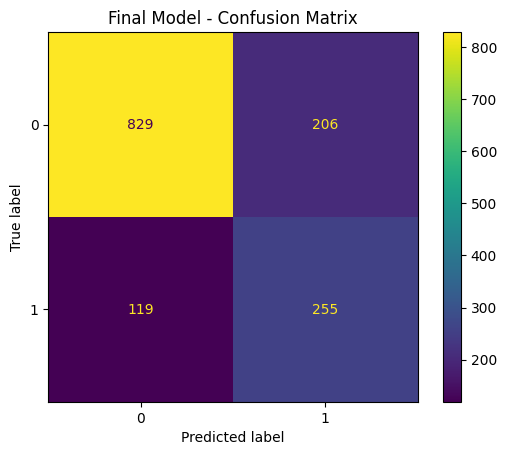

In [80]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred
)

plt.title(
    "Final Model - Confusion Matrix"
)

plt.show()

In [81]:
preprocessor_fitted = best_model.named_steps[
    "preprocessor"
]

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

print(
    "Number of features:",
    len(feature_names)
)

Number of features: 5683


In [82]:
rf = best_model.named_steps[
    "model"
]

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

display(
    feature_importance.head(20)
)

,Feature,Importance
1,num__tenure,0.068970
3,num__TotalCharges,0.057164
2,num__MonthlyCharges,0.046867
4,num__AverageMonthlySpend,0.043570
5671,cat__Contract_Month-to-month,0.035673
5653,cat__OnlineSecurity_No,0.029413
5673,cat__Contract_Two year,0.029124
5662,cat__TechSupport_No,0.027108
5682,cat__TenureGroup_New,0.026413
5678,cat__PaymentMethod_Electronic check,0.024325


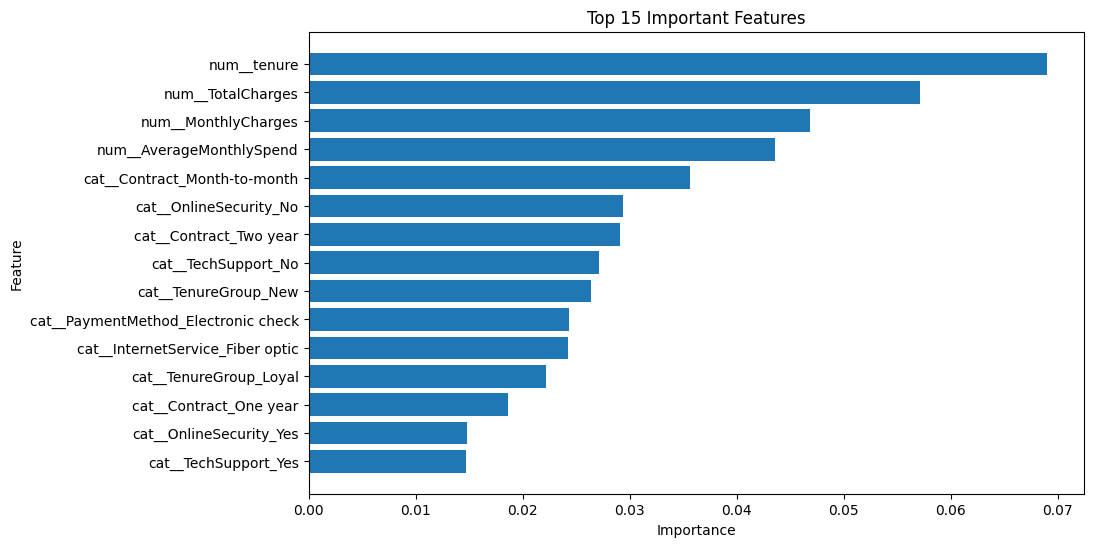

In [83]:
top_features = (
    feature_importance
    .head(15)
    .sort_values(
        "Importance"
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(
    "Top 15 Important Features"
)

plt.show()

In [86]:
new_customer = pd.DataFrame({
    "gender": ["Female"],
    "SeniorCitizen": [0],
    "customerID": ["9999-9999"],
    "Partner": ["Yes"],
    "Dependents": ["No"],
    "tenure": [2],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["No"],
    "DeviceProtection": ["No"],
    "TechSupport": ["No"],
    "StreamingTV": ["Yes"],
    "StreamingMovies": ["Yes"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": [
        "Electronic check"
    ],
    "MonthlyCharges": [85.0],
    "TotalCharges": [170.0],
    "TenureGroup": ["New"],
    "AverageMonthlySpend": [85.0]
})

new_customer

,gender,SeniorCitizen,customerID,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,TenureGroup,AverageMonthlySpend
0,Female,0,9999-9999,Yes,No,2,Yes,No,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,85.0,170.0,New,85.0


In [87]:
prediction = best_model.predict(
    new_customer
)[0]

probability = best_model.predict_proba(
    new_customer
)[0, 1]

print(
    "Prediction:",
    "Churn" if prediction == 1
    else "Stay"
)

print(
    f"Churn probability: "
    f"{probability:.2%}"
)

Prediction: Churn
Churn probability: 86.76%


In [88]:
joblib.dump(
    best_model,
    "customer_churn_model.pkl"
)

print(
    "Model saved successfully!"
)

Model saved successfully!


In [89]:
loaded_model = joblib.load(
    "customer_churn_model.pkl"
)

prediction = loaded_model.predict(
    new_customer
)

print(
    prediction
)

[1]
